In [29]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [30]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

df["hour"] = df["hour"].astype(int) - 1
df["day_of_week"] = df["day_of_week"].astype(int)
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

In [31]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']
target_col = "load"

In [32]:
SEQ_LEN = 24

class DatasetRQ6(Dataset):
    def __init__(self, df):
        self.Xl = df[load_features].values.astype(np.float32)
        self.Xt = df[temp_features].values.astype(np.float32)
        self.Xc = df[calendar_features].values.astype(np.int64)
        self.y = df[target_col].values.astype(np.float32)

    def __len__(self):
        return len(self.Xl) - SEQ_LEN

    def __getitem__(self, idx):
        return (
            torch.tensor(self.Xl[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xt[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xc[idx:idx+SEQ_LEN]),
            torch.tensor(self.y[idx+SEQ_LEN])
        )

In [33]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        self.fc = nn.Sequential(
            nn.Linear(64 + 32 + 18, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        cal = torch.cat([
            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])
        ], dim=1)

        fused = torch.cat([load_out, temp_out, cal], dim=1)
        return self.fc(fused)

In [34]:
class AdaptiveFusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        # 🔥 Attention weights
        self.attention = nn.Sequential(
            nn.Linear(64 + 32 + 18, 32),
            nn.ReLU(),
            nn.Linear(32, 3),
            nn.Sigmoid()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 + 32 + 18, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        cal = torch.cat([
            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])
        ], dim=1)

        combined = torch.cat([load_out, temp_out, cal], dim=1)

        weights = self.attention(combined)

        # Split weights
        w_load = weights[:, 0].unsqueeze(1)
        w_temp = weights[:, 1].unsqueeze(1)
        w_cal = weights[:, 2].unsqueeze(1)

        # Apply weights
        fused = torch.cat([
            load_out * (1 + w_load),
            temp_out * (1 + w_temp),
            cal * (1 + w_cal)
        ], dim=1)

        return self.fc(fused), weights

In [35]:
def train_model(model, train_loader, epochs=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for Xl, Xt, Xc, y in train_loader:
            Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

            optimizer.zero_grad()

            if isinstance(model, AdaptiveFusionModel):
                preds, _ = model(Xl, Xt, Xc)
            else:
                preds = model(Xl, Xt, Xc)

            loss = criterion(preds.squeeze(), y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

In [36]:
def evaluate_adaptive(model, loader):
    model.eval()
    preds, actuals, weights_list = [], [], []

    with torch.no_grad():
        for Xl, Xt, Xc, y in loader:
            Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

            out, weights = model(Xl, Xt, Xc)

            preds.extend(out.cpu().numpy().flatten())
            actuals.extend(y.numpy().flatten())
            weights_list.append(weights.cpu().numpy())

    return np.array(preds), np.array(actuals), np.vstack(weights_list)

In [37]:
dataset = DatasetRQ6(df)

train_size = int(0.8 * len(dataset))
train_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, len(dataset) - train_size]
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [38]:
baseline_model = BaselineModel().to(device)
adaptive_model = AdaptiveFusionModel().to(device)

In [39]:
print("Training Baseline Model...")
train_model(baseline_model, train_loader)

print("\nTraining Adaptive Fusion Model...")
train_model(adaptive_model, train_loader)

Training Baseline Model...
Epoch 1 | Loss: 943372191.7812
Epoch 2 | Loss: 126698912.5000
Epoch 3 | Loss: 43913656.1758
Epoch 4 | Loss: 29660671.1943
Epoch 5 | Loss: 27374487.8691
Epoch 6 | Loss: 25987863.0586
Epoch 7 | Loss: 25417521.3818
Epoch 8 | Loss: 24919011.4619
Epoch 9 | Loss: 24582942.0576
Epoch 10 | Loss: 24544749.7559
Epoch 11 | Loss: 24276536.7852
Epoch 12 | Loss: 24177888.2422
Epoch 13 | Loss: 23942069.2012
Epoch 14 | Loss: 23839792.9336
Epoch 15 | Loss: 23775218.8799
Epoch 16 | Loss: 23630307.6426
Epoch 17 | Loss: 23544146.2793
Epoch 18 | Loss: 23542659.3369
Epoch 19 | Loss: 23427514.2627
Epoch 20 | Loss: 23395323.0654

Training Adaptive Fusion Model...
Epoch 1 | Loss: 833763213.4062
Epoch 2 | Loss: 76428884.6250
Epoch 3 | Loss: 30810340.9629
Epoch 4 | Loss: 26147011.5234
Epoch 5 | Loss: 24416008.5791
Epoch 6 | Loss: 23785922.0303
Epoch 7 | Loss: 23147217.2344
Epoch 8 | Loss: 22716404.7798
Epoch 9 | Loss: 22413714.5166
Epoch 10 | Loss: 22461965.3594
Epoch 11 | Loss: 222731

In [40]:
def evaluate_baseline(model, loader):
    model.eval()
    preds, actuals = [], []

    with torch.no_grad():
        for Xl, Xt, Xc, y in loader:
            Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

            out = model(Xl, Xt, Xc)

            preds.extend(out.cpu().numpy().flatten())
            actuals.extend(y.numpy().flatten())

    return np.array(preds), np.array(actuals)

In [41]:
# Baseline
preds_baseline, actuals = evaluate_baseline(baseline_model, test_loader)

# Adaptive
preds_adaptive, actuals_adapt, weights = evaluate_adaptive(adaptive_model, test_loader)

In [42]:
preds_baseline = preds_baseline.flatten()
preds_adaptive = preds_adaptive.flatten()
actuals = actuals.flatten()

In [43]:
mae_baseline = mean_absolute_error(actuals, preds_baseline)
rmse_baseline = np.sqrt(mean_squared_error(actuals, preds_baseline))

mae_adaptive = mean_absolute_error(actuals, preds_adaptive)
rmse_adaptive = np.sqrt(mean_squared_error(actuals, preds_adaptive))

results = pd.DataFrame({
    "Model": ["Baseline", "Adaptive Fusion"],
    "MAE": [mae_baseline, mae_adaptive],
    "RMSE": [rmse_baseline, rmse_adaptive]
})

results.to_csv("outputs/tables/rq6_results.csv", index=False)
results

,Model,MAE,RMSE
0,Baseline,117.238754,153.457025
1,Adaptive Fusion,108.958420,144.994760


In [44]:
avg_weights = weights.mean(axis=0)

attention_df = pd.DataFrame({
    "Modality": ["Load", "Temperature", "Calendar"],
    "Average Weight": avg_weights
})

attention_df.to_csv("outputs/tables/rq6_attention_weights.csv", index=False)
attention_df

,Modality,Average Weight
0,Load,1.0
1,Temperature,1.0
2,Calendar,1.0


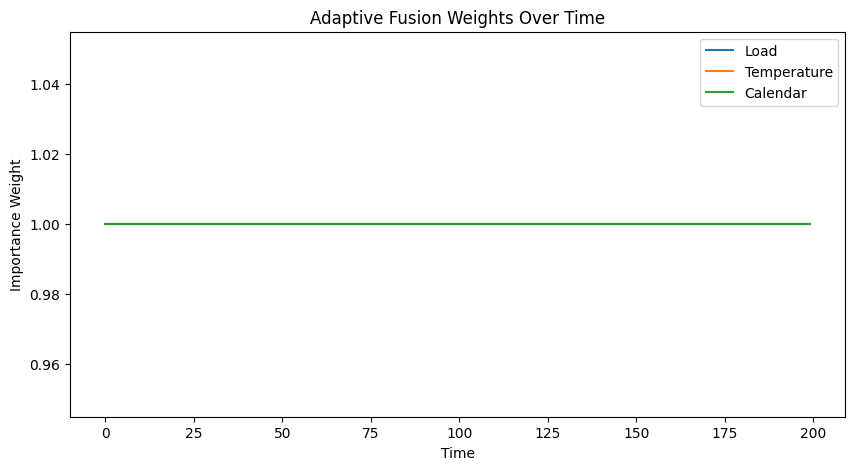

In [45]:
plt.figure(figsize=(10,5))

plt.plot(weights[:200, 0], label="Load")
plt.plot(weights[:200, 1], label="Temperature")
plt.plot(weights[:200, 2], label="Calendar")

plt.legend()
plt.title("Adaptive Fusion Weights Over Time")
plt.xlabel("Time")
plt.ylabel("Importance Weight")

plt.savefig("outputs/figures/rq6_attention_over_time.pdf")
plt.show()

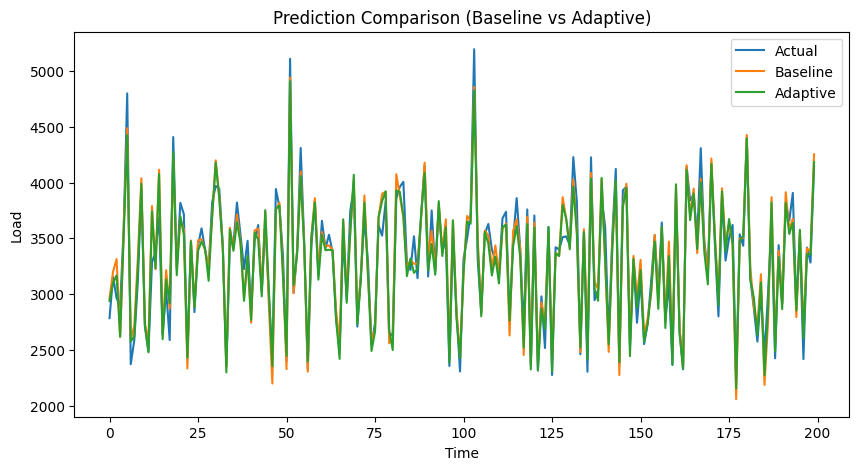

In [46]:
plt.figure(figsize=(10,5))

plt.plot(actuals[:200], label="Actual")
plt.plot(preds_baseline[:200], label="Baseline")
plt.plot(preds_adaptive[:200], label="Adaptive")

plt.legend()
plt.title("Prediction Comparison (Baseline vs Adaptive)")
plt.xlabel("Time")
plt.ylabel("Load")

plt.savefig("outputs/figures/rq6_predictions.pdf")
plt.show()